In [ ]:
# !pip install matplotlib pandas numpy scikit-learn joblib fg-data-profiling seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport

/tmp/ipykernel_2108/3064018226.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
def load_data(path):
  return pd.read_csv(path)

df = load_data("dataset-bank.csv")
profile = ProfileReport(df)
df.head().round()
df.tail().round()
df.groupby('CUST_ID')["CUST_ID"].count().sort_values(ascending=False)
df = df.drop(columns=["CUST_ID"])
df.shape
# profile

(8950, 7)

In [ ]:
def describe_data():
  return df.describe().T.round()
describe_data()

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.0,2082.0,0.0,128.0,873.0,2054.0,19043.0
PURCHASES,8950.0,1003.0,2137.0,0.0,40.0,361.0,1110.0,49040.0
ONEOFF_PURCHASES,8950.0,592.0,1660.0,0.0,0.0,38.0,577.0,40761.0
INSTALLMENTS_PURCHASES,8950.0,411.0,904.0,0.0,0.0,89.0,469.0,22500.0
CASH_ADVANCE,8950.0,979.0,2097.0,0.0,0.0,0.0,1114.0,47137.0
CREDIT_LIMIT,8949.0,4494.0,3639.0,50.0,1600.0,3000.0,6500.0,30000.0
PAYMENTS,8950.0,1733.0,2895.0,0.0,383.0,857.0,1901.0,50721.0


In [ ]:
def get_corr():
  return df.corr()

get_corr()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
BALANCE,1.000000,0.181261,0.164350,0.126469,0.496692,0.531283,0.322802
PURCHASES,0.181261,1.000000,0.916845,0.679896,-0.051474,0.356963,0.603264
ONEOFF_PURCHASES,0.164350,0.916845,1.000000,0.330622,-0.031326,0.319724,0.567292
INSTALLMENTS_PURCHASES,0.126469,0.679896,0.330622,1.000000,-0.064244,0.256499,0.384084
CASH_ADVANCE,0.496692,-0.051474,-0.031326,-0.064244,1.000000,0.303985,0.453238
CREDIT_LIMIT,0.531283,0.356963,0.319724,0.256499,0.303985,1.000000,0.421861
PAYMENTS,0.322802,0.603264,0.567292,0.384084,0.453238,0.421861,1.000000


In [ ]:
def missing_table():
    return pd.DataFrame({
        "number": df.isna().sum(),
        "percent": ((df.isna().sum() / len(df)) * 100).round(2)
    })

missing_table()

,number,percent
BALANCE,0,0.00
PURCHASES,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
CREDIT_LIMIT,1,0.01
PAYMENTS,0,0.00


<Axes: >

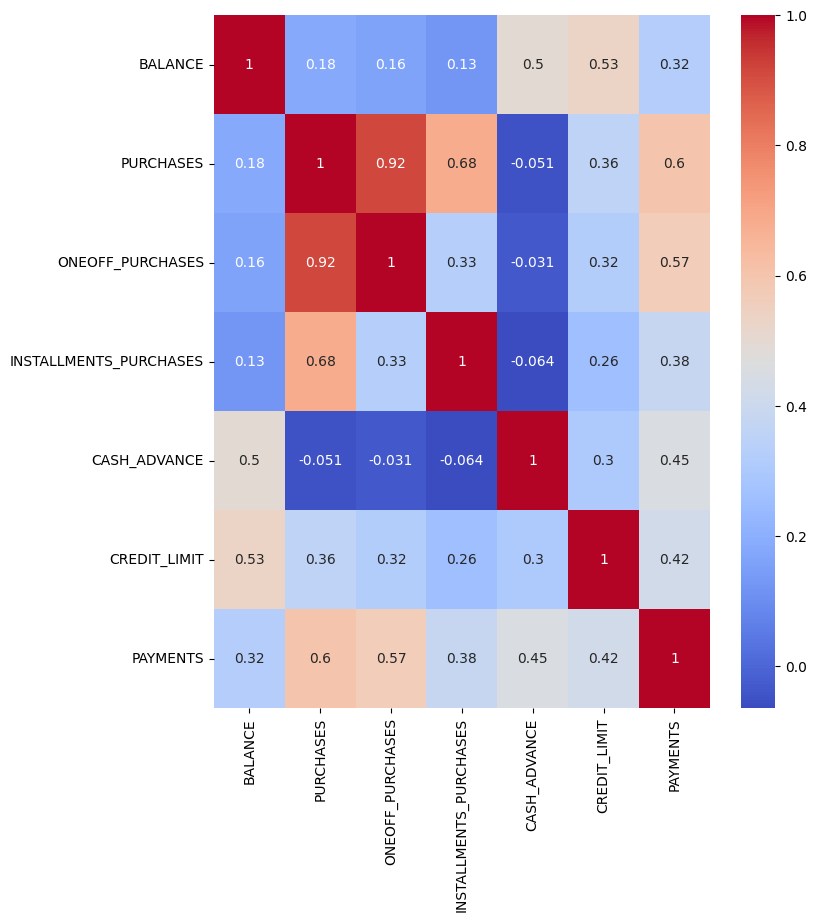

In [ ]:
plt.figure(figsize=(8, 9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [ ]:
def get_outliers(col : str):
  q1, q3 = df[col].quantile([0.2, 0.75])
  iqr = q3 - q1
  lower_value = q1 - 1.5*iqr
  max_value = q3 + 1.5*iqr

  mask = (df[col] < lower_value) | (df[col] > max_value)
  return df[mask], mask

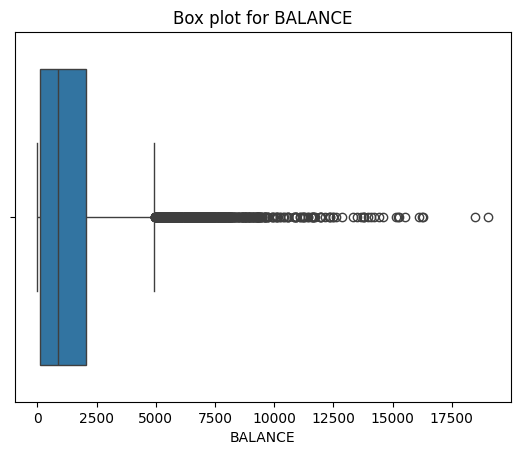

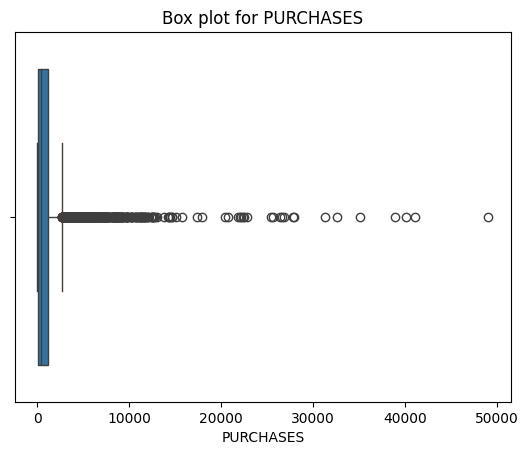

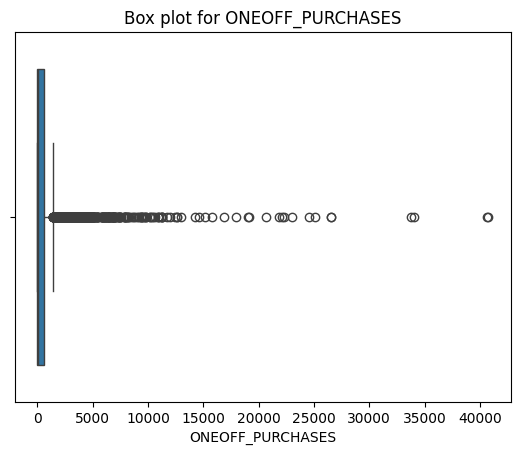

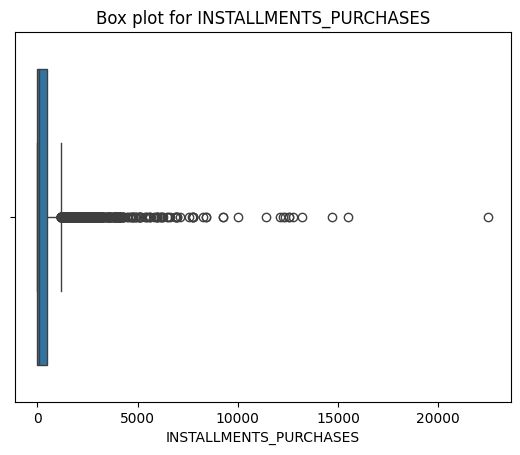

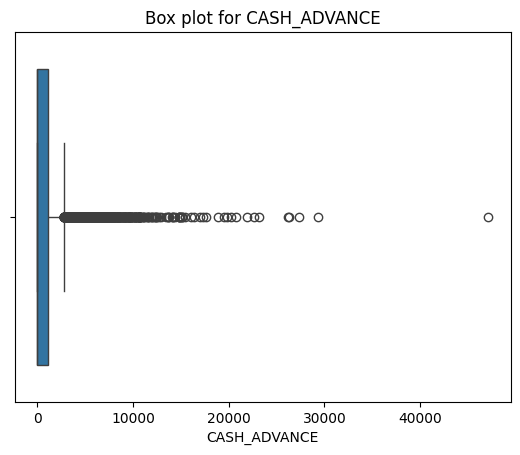

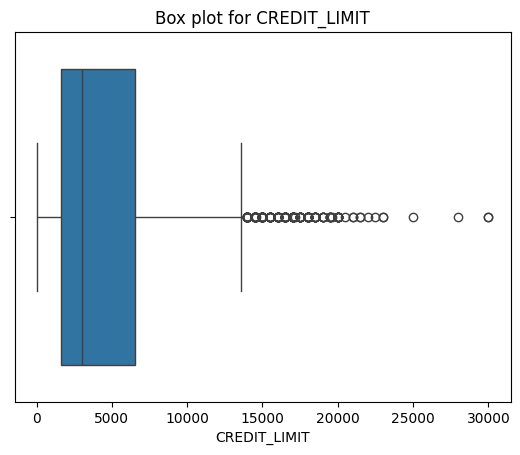

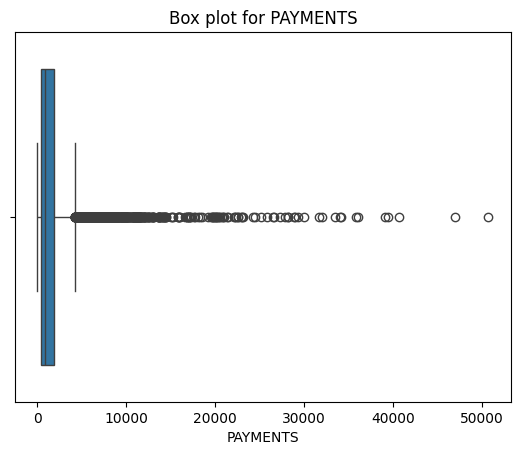

In [ ]:
def make_boxplots():
  for col in df.columns:
    sns.boxplot(x=df[col])
    plt.title(f"Box plot for {col}")
    plt.show()
make_boxplots()

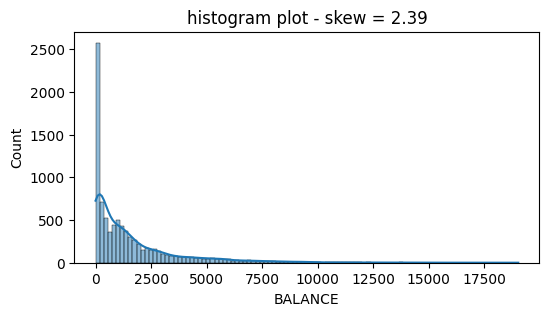

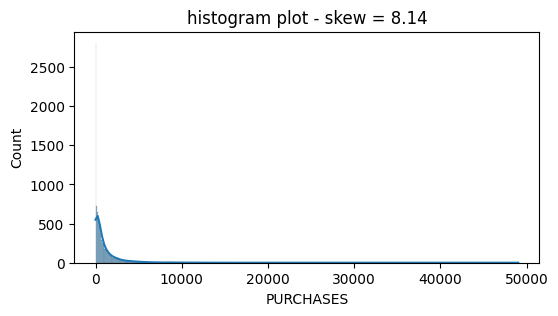

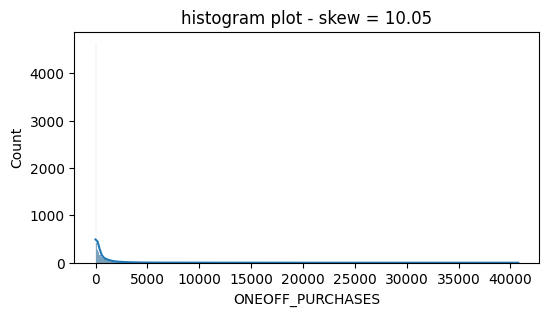

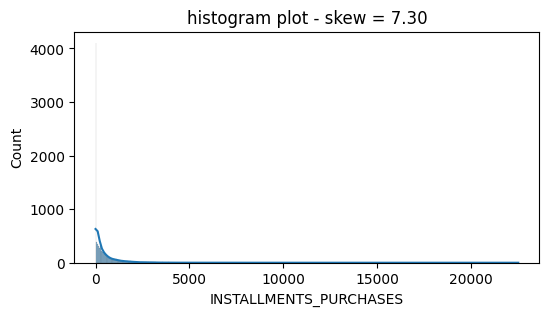

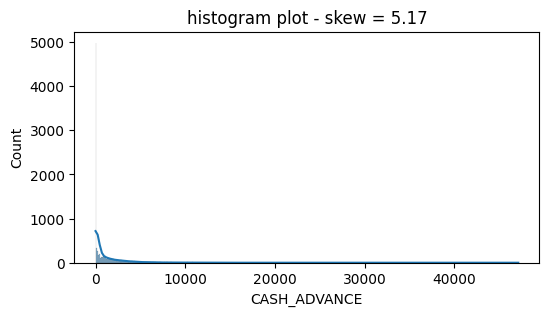

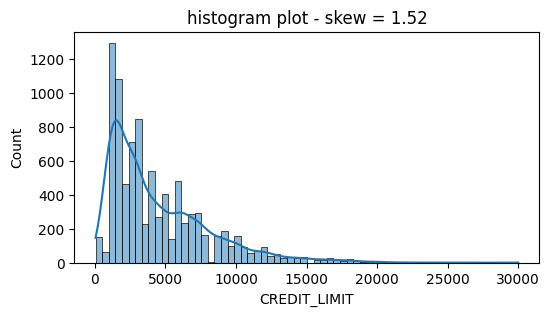

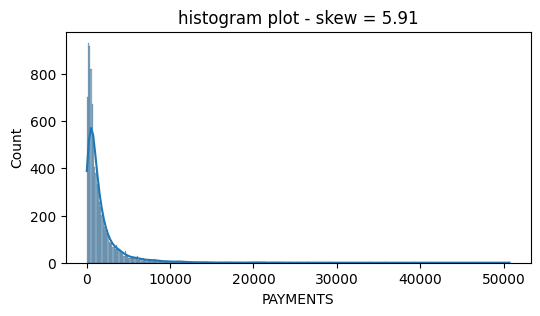

In [ ]:
def make_hists():
  for col in df.columns:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde = True)
    plt.title(f"histogram plot - skew = {df[col].skew():0.2f}")
    plt.show()
make_hists()

In [ ]:
## traitment dyal data

In [ ]:
def remove_duplicates():
  df.drop_duplicates(inplace=True)
  df.reset_index(inplace=True, drop=True)
remove_duplicates()

In [ ]:
def drop_null():
  df.dropna(subset=['CREDIT_LIMIT'], inplace=True)
  df.reset_index(inplace=True, drop=True)
drop_null()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X = df.copy()
x_scaled = StandardScaler().fit_transform(np.log1p(df))

pca = PCA()
pca.fit_transform(x_scaled)

explained = pca.explained_variance_ratio_
accumulated = np.cumsum(explained)

pca_data = pd.DataFrame({
    "pca": [f"PC{i}" for i in range(0, len(explained))],
    "Variance_Explained": explained,
    "Variance_accumulated": accumulated
})


target = 0.8
found_n_components = np.argmax(accumulated >= 0.8) + 1

pca_data


,pca,Variance_Explained,Variance_accumulated
0,PC0,0.353624,0.353624
1,PC1,0.292585,0.646209
2,PC2,0.113970,0.760179
3,PC3,0.100054,0.860233
4,PC4,0.076266,0.936498
5,PC5,0.049700,0.986199
6,PC6,0.013801,1.000000


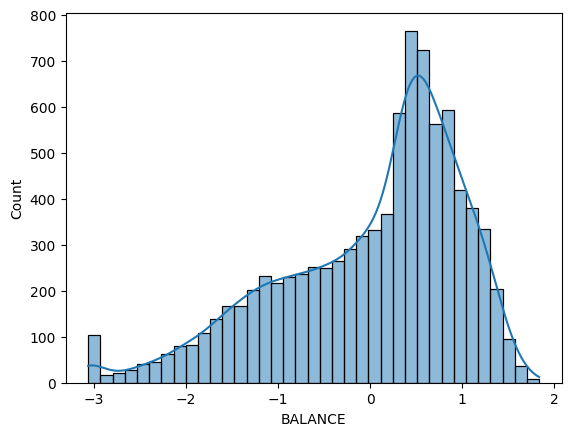

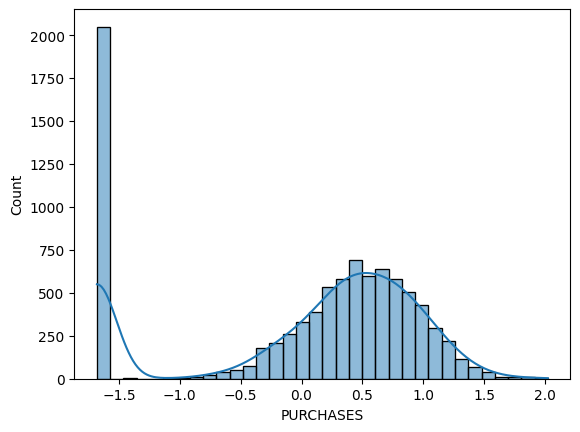

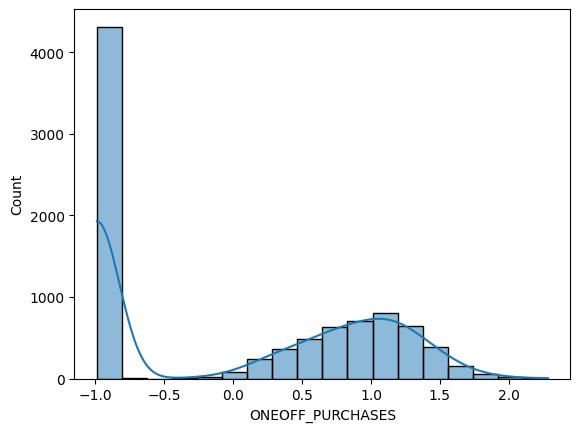

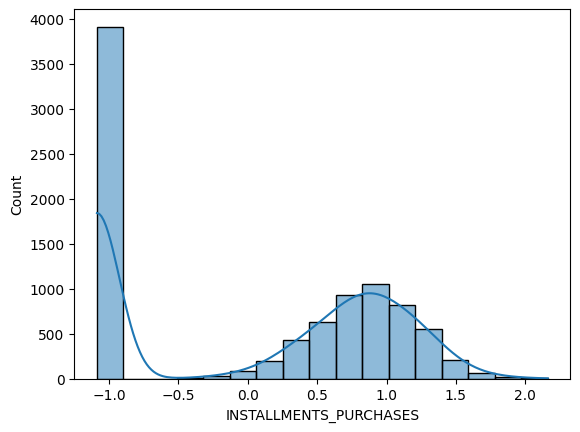

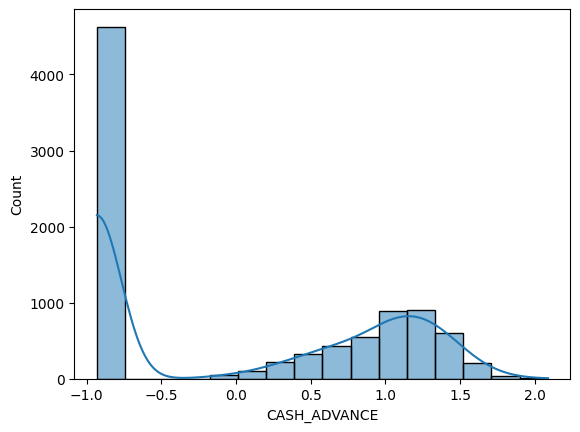

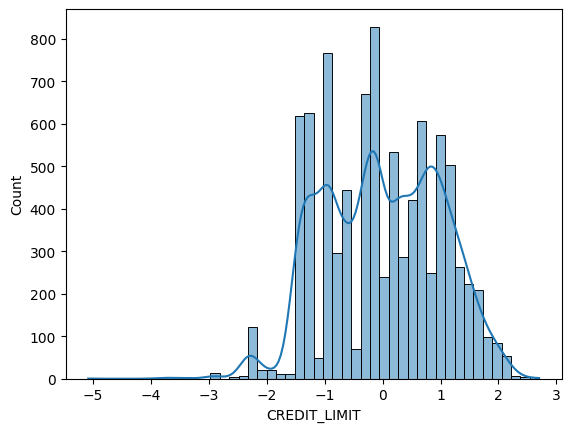

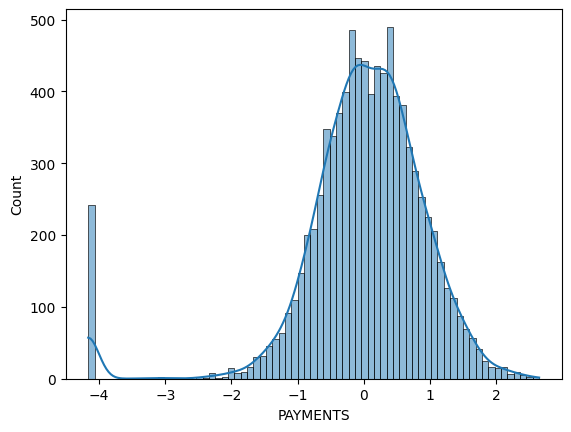

In [ ]:
for col in X.columns:
  sns.histplot(pd.DataFrame(x_scaled, columns=X.columns)[col], kde=True)
  plt.show()

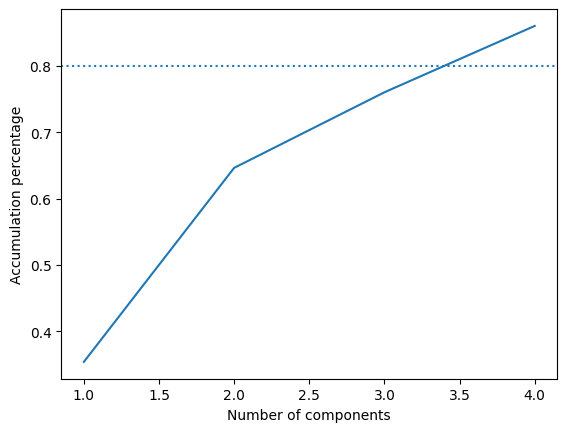

In [ ]:

sns.lineplot(x=np.arange(1, found_n_components + 1), y=accumulated[:found_n_components])
plt.axhline(y=0.8, linestyle=':')
plt.xlabel('Number of components')
plt.ylabel('Accumulation percentage')
plt.show()

In [ ]:
pca_data = PCA(found_n_components).fit_transform(x_scaled)
x_pca_data = pd.DataFrame(pca_data)
x_pca_data

,0,1,2,3
0,-0.457236,-2.343430,-0.574133,-0.425904
1,-2.100598,2.188513,-0.561805,0.616495
2,0.829442,0.714435,1.569019,0.517618
3,-0.334924,-0.589284,3.087780,1.127924
4,-0.940884,-0.636421,0.604596,-0.870138
...,...,...,...,...
8944,0.008679,-2.373310,-0.881916,-0.502134
8945,0.002344,-2.534881,-0.843803,-0.426232
8946,-0.425151,-2.793521,-0.435997,-0.255900
8947,-2.793256,-2.638398,0.485540,-0.693736


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


results = []

for n in range(2, 6):
  pca = PCA(n_components=n, random_state=42)
  x_pca = pca.fit_transform(x_scaled)

  for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(x_pca)

    results.append({
        "n_components": n,
          "k": k,
          "inertie": km.inertia_,
          "silhouette": silhouette_score(x_pca, labels),
    })

results = pd.DataFrame(results)
results


,n_components,k,inertie,silhouette
0,2,2,23542.395938,0.430953
1,2,3,13244.219895,0.448740
2,2,4,10414.983259,0.421660
3,2,5,8242.980510,0.410122
4,2,6,6689.621477,0.394669
5,2,7,5634.987347,0.397941
6,3,2,30681.084633,0.368307
7,3,3,20205.727848,0.382649
8,3,4,16448.250736,0.388787
9,3,5,13781.047480,0.390872


In [ ]:
pivot = results.pivot(index='n_components', columns="k", values="silhouette")


In [ ]:
results

,n_components,k,inertie,silhouette
0,2,2,23542.395938,0.430953
1,2,3,13244.219895,0.448740
2,2,4,10414.983259,0.421660
3,2,5,8242.980510,0.410122
4,2,6,6689.621477,0.394669
5,2,7,5634.987347,0.397941
6,3,2,30681.084633,0.368307
7,3,3,20205.727848,0.382649
8,3,4,16448.250736,0.388787
9,3,5,13781.047480,0.390872


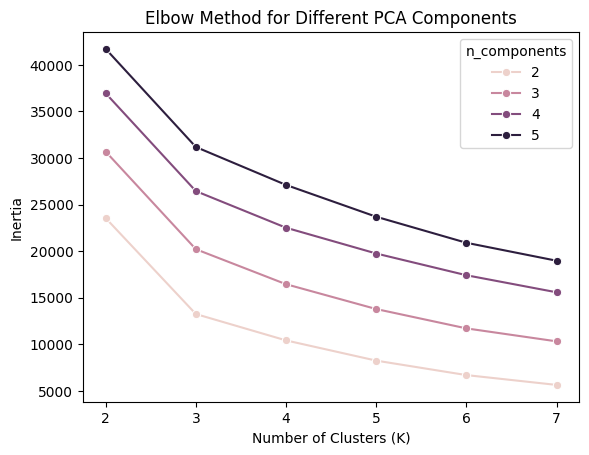

In [ ]:
sns.lineplot(data=results, x='k', y='inertie', hue="n_components", marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Different PCA Components")
plt.show()

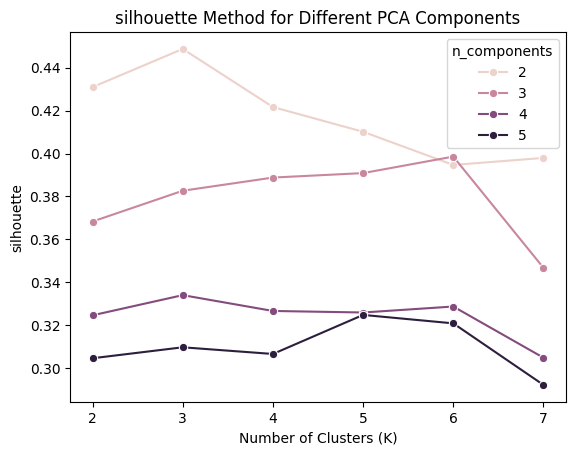

In [ ]:
sns.lineplot(x='k', y='silhouette', hue="n_components", data=results, marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("silhouette")
plt.title("silhouette Method for Different PCA Components")
plt.show()

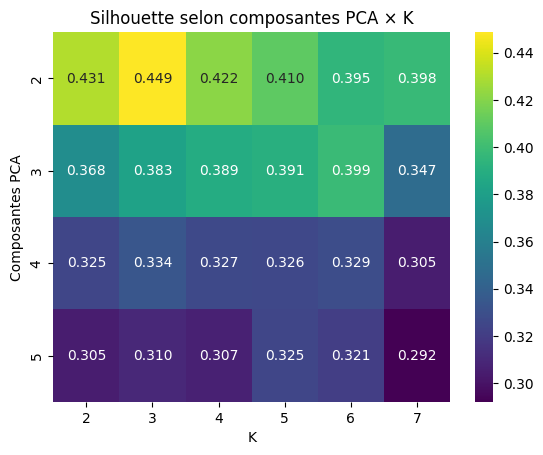

In [ ]:
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Silhouette selon composantes PCA × K")
plt.xlabel("K")
plt.ylabel("Composantes PCA")
plt.show()

In [ ]:
best = results.loc[results['silhouette'].argmax()]
best_n = int(best['n_components'])
best_k = int(best['k'])

best_k, best_n

# khdem b best pca
best_pca = PCA(n_components=best_n, random_state=42)
data_best_pca = pd.DataFrame(best_pca.fit_transform(x_scaled), columns=[f'PC{i}' for i in range(best_n)])

best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = best_km.fit_predict(data_best_pca)

inertia = best_km.inertia_
silhouette = silhouette_score(data_best_pca, labels)

data_best_pca['clusters'] = labels
data_best_pca

,PC0,PC1,clusters
0,-0.457236,-2.343430,2
1,-2.100598,2.188513,0
2,0.829442,0.714435,1
3,-0.334924,-0.589284,2
4,-0.940884,-0.636421,2
...,...,...,...
8944,0.008679,-2.373310,2
8945,0.002344,-2.534881,2
8946,-0.425151,-2.793521,2
8947,-2.793256,-2.638398,2


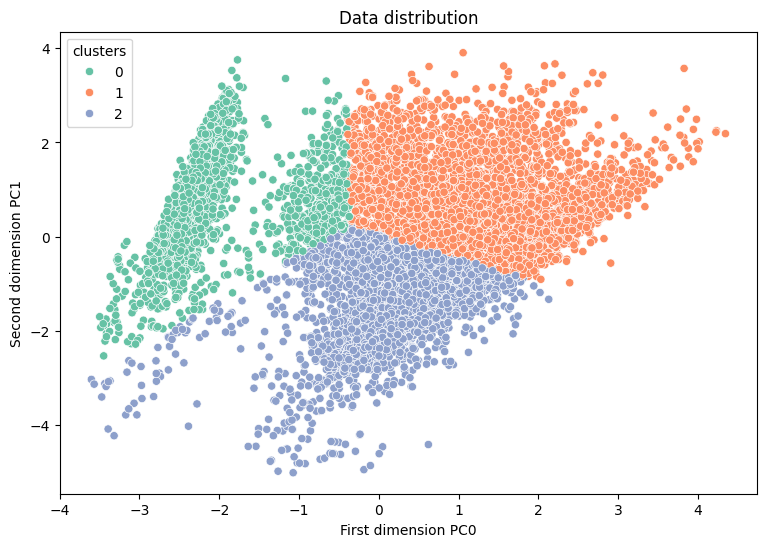

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x="PC0", y="PC1", data=data_best_pca, hue="clusters", palette="Set2")
plt.title("Data distribution")
plt.xlabel("First dimension PC0")
plt.ylabel("Second doimension PC1")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

n_component_range = np.arange(2, 6)
k_range = np.arange(2, 8)
k_range = np.arange(2, 8)

In [ ]:
from sklearn.cluster import DBSCAN


results = []

for n in range(2, 6):
    pca = PCA(n_components=n, random_state=42)
    x_pca = pca.fit_transform(x_scaled)

    for eps in [0.2, 0.3, 0.5, 0.7, 1.0]:
        for ms in [5, 10, 20]:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(x_pca)

            noise = labels == -1
            n_clusters = len(set(labels)) - (1 if noise.any() else 0)

            if n_clusters < 2: continue

            silhouette = silhouette_score(x_pca[~noise] ,labels[~noise])
            results.append({
                "k" : n_clusters,
                "n_components" : n,
                "eps" : eps,
                "silhouette" : silhouette,
                "noise_percentage" : noise.mean() * 100,
            })


<Axes: xlabel='k', ylabel='silhouette'>

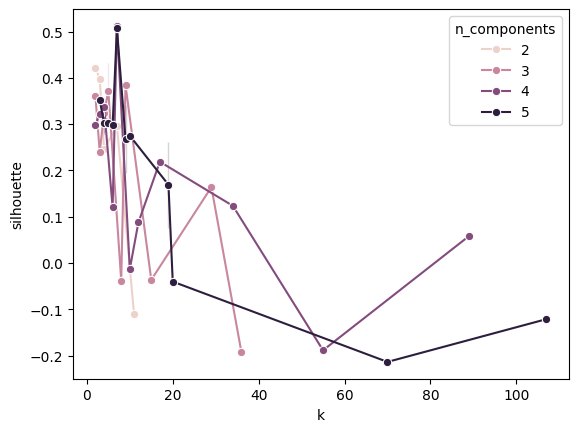

In [ ]:
results = pd.DataFrame(results)
sns.lineplot(data=results, y='silhouette', x="k", hue="n_components", marker="o")


In [ ]:
results.sort_values(by=["noise_percentage", 'silhouette'], ascending=[True, False]).round(2)


,k,n_components,eps,silhouette,noise_percentage
3,2,2,0.3,0.42,0.30
12,3,3,0.5,0.24,0.53
40,5,5,1.0,0.30,0.69
25,6,4,0.7,0.12,0.85
15,2,3,0.7,0.36,0.98
41,5,5,1.0,0.30,1.01
4,3,2,0.3,0.39,1.03
13,5,3,0.5,0.31,1.14
0,11,2,0.2,-0.11,1.39
26,2,4,0.7,0.30,2.12
